# NB-GP Normative Modeling — cfRNA Application

In [31]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import gpytorch
import scanpy as sc
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from scipy.sparse import issparse
from scipy.stats import nbinom, norm
from scipy.special import gammaln
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from nb_models import NBGLM, BayesianNBGLM, LaplaceNBGP, train_bayesian_nbglm, train_laplace_nbgp, compute_zscore, score_glm, score_bayes_glm, score_laplace

torch.manual_seed(42)
np.random.seed(42)

In [32]:
DATA_DIR  = Path("/project/cfRNA_NormativeModeling/OpenAccess_nfcore")
H5AD_PATH = DATA_DIR / "Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BIAS_COLUMNS = [
    "log(Total Reads)",
    "Spliced Reads (%)",
    "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction",
    "RNA Degradation (3' Bias)",
    "Platelet Score",
    "GC Bias",
    "Gene Length Bias",
    "NG80",
    "(NP80/NG80)",
]

print(f"Device   : {DEVICE}")
print(f"Data path: {H5AD_PATH}")

Device   : cuda
Data path: /project/cfRNA_NormativeModeling/OpenAccess_nfcore/Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad


In [33]:
adata = sc.read_h5ad(H5AD_PATH)
adata = adata[adata.obs["QC_Passed"] == True]
adata = adata[adata.obs["Phenotype_Processed"].notna()]
adata = adata[adata.obs["Phenotype_Processed"] != "Unknown"]
phenotypes = adata.obs["Phenotype_Processed"].astype(str).values
is_hc      = phenotypes == "Healthy Control"
# ── X: bias metric normalization (fit on HC only) ─────────────────
X_raw        = adata.obs[BIAS_COLUMNS].values.astype(np.float32)
scaler_X     = StandardScaler()
X_hc_scaled  = scaler_X.fit_transform(X_raw[is_hc])
X_all_scaled = scaler_X.transform(X_raw)
# ── Y: raw counts (rounded to nearest integer) ────────────────────
Y_raw = adata.X.toarray() if issparse(adata.X) else np.asarray(adata.X)
Y_raw = np.round(Y_raw).astype(np.float32)
# ── Protein-coding gene filter ────────────────────────────────────
is_pc          = (adata.var["GeneType"] == "protein_coding").values
pc_gene_names  = adata.var_names[is_pc].tolist()
pc_indices     = np.where(is_pc)[0]
# ── Disease group info ────────────────────────────────────────────
unique_diseases = sorted(set(phenotypes[~is_hc]) - {"nan", "Unknown", "None"})

print(f"Total samples  : {len(adata)}")
print(f"  HC           : {is_hc.sum()} | Disease: {(~is_hc).sum()}")
print(f"Protein-coding : {len(pc_gene_names)} genes")
print(f"X shape (HC)   : {X_hc_scaled.shape}")
print(f"Disease groups : {unique_diseases}")
print(f"Y_raw dtype    : {Y_raw.dtype}, sample values: {Y_raw[0, :5]}")

Total samples  : 3159
  HC           : 996 | Disease: 2163
Protein-coding : 20097 genes
X shape (HC)   : (996, 10)
Disease groups : ['AD', 'AML', 'CDCS', 'Colorectal Cancer', 'Diverticulitis', 'EPO_Treatment', 'Esophagus Cancer', 'GCSF_Donor', 'HIV', 'HIV + Tuberculosis', 'ICI-m ', 'ICI-treated Cancer', 'Liver Cancer', 'Liver Cirrhosis', 'Lung Cancer', 'ME/CFS', 'MGUS', 'MM', 'NAFLD', 'NASH', 'Other Cancer', 'Pancreatic Cancer', 'Pancreatic Cancer ', 'Pancreatitis', 'Pre-eclampsia', 'Stomach Cancer', 'Tuberculosis', 'Unspecified_Fibrosis']
Y_raw dtype    : float32, sample values: [ 0.  0.  0. 26. 35.]


In [34]:
# =====================================================================
# Stratified gene selection  (quantile-based bins)
# =====================================================================
# 1. Candidate filter : det_rate_hc >= 0.1  AND  mean_count_hc >= 2.0
# 2. Stratification   : 4×4 grid using quartiles of the CANDIDATE distribution
#    → each axis split at Q25/Q50/Q75 of candidates → ~equal pool per stratum
# 3. Selection        : up to k genes per stratum (random, seed-fixed)
# =====================================================================

K_PER_STRATUM = 4
GENE_SEED     = 42


def select_stratified_genes(
    Y_raw, is_hc, pc_gene_names, pc_indices,
    det_rate_min=0.1, mean_count_min=2.0,
    n_det_bins=4, n_count_bins=4,
    k=K_PER_STRATUM, seed=GENE_SEED,
):
    """
    Returns (target_names, target_indices, df_strata).
    Bin edges are derived from the quartiles of the candidate gene distribution
    so that each stratum has roughly equal numbers of candidate genes.
    """
    Y_hc   = Y_raw[is_hc][:, pc_indices]
    det_r  = (Y_hc > 0).mean(axis=0).astype(float)
    mean_c = Y_hc.mean(axis=0).astype(float)

    cand      = (det_r >= det_rate_min) & (mean_c >= mean_count_min)
    c_names   = np.array(pc_gene_names)[cand]
    c_indices = pc_indices[cand]
    c_det     = det_r[cand]
    c_mean    = mean_c[cand]

    # Quantile edges from the candidate pool
    det_q   = np.quantile(c_det,  np.linspace(0, 1, n_det_bins   + 1))
    count_q = np.quantile(c_mean, np.linspace(0, 1, n_count_bins + 1))
    # Replace the upper bound of the last bin with inf so max values are included
    det_edges   = list(det_q[:-1])   + [np.inf]
    count_edges = list(count_q[:-1]) + [np.inf]

    rng = np.random.default_rng(seed)
    sel_names, sel_indices, strata_rows = [], [], []

    for d_lo, d_hi in zip(det_edges[:-1], det_edges[1:]):
        for m_lo, m_hi in zip(count_edges[:-1], count_edges[1:]):
            in_bin = np.where(
                (c_det  >= d_lo) & (c_det  < d_hi) &
                (c_mean >= m_lo) & (c_mean < m_hi)
            )[0]
            n_avail  = len(in_bin)
            n_chosen = min(k, n_avail)
            chosen   = rng.choice(in_bin, size=n_chosen, replace=False) if n_chosen > 0 else []

            for ci in chosen:
                sel_names.append(c_names[ci])
                sel_indices.append(c_indices[ci])

            d_hi_s = f"{d_hi:.3f}" if d_hi < np.inf else "∞"
            m_hi_s = f"{m_hi:.1f}" if m_hi < np.inf else "∞"
            strata_rows.append({
                "det_bin":   f"[{d_lo:.3f}, {d_hi_s})",
                "count_bin": f"[{m_lo:.1f}, {m_hi_s})",
                "n_cand":    n_avail,
                "n_sel":     n_chosen,
            })

    df_strata = pd.DataFrame(strata_rows)
    return list(sel_names), np.array(sel_indices), df_strata


target_names, target_indices, df_strata = select_stratified_genes(
    Y_raw, is_hc, pc_gene_names, pc_indices
)

# ── Summary ──────────────────────────────────────────────────────
Y_hc_pc = Y_raw[is_hc][:, pc_indices]
n_cand  = (((Y_hc_pc > 0).mean(0) >= 0.1) & (Y_hc_pc.mean(0) >= 2.0)).sum()

print(f"Candidate genes (det≥0.1, mean≥2): {n_cand}")
print(f"Selected target genes : {len(target_names)}  "
      f"(up to {K_PER_STRATUM}/stratum × {len(df_strata)} strata)")
print()

pivot_cand = df_strata.pivot_table(
    index="count_bin", columns="det_bin", values="n_cand", aggfunc="first"
)
pivot_sel = df_strata.pivot_table(
    index="count_bin", columns="det_bin", values="n_sel", aggfunc="first"
)
print("=== n_cand (candidates per stratum) ===")
print(pivot_cand.to_string())
print("\n=== n_sel (selected per stratum) ===")
print(pivot_sel.to_string())


Candidate genes (det≥0.1, mean≥2): 15185
Selected target genes : 52  (up to 4/stratum × 16 strata)

=== n_cand (candidates per stratum) ===
det_bin        [0.102, 0.641)  [0.641, 0.915)  [0.915, 0.984)  [0.984, ∞)
count_bin                                                                
[18.0, 76.4)              259            3107             430           0
[2.0, 18.0)              3514             282               0           0
[246.4, ∞)                  4              27             445        3321
[76.4, 246.4)              16             377            2874         529

=== n_sel (selected per stratum) ===
det_bin        [0.102, 0.641)  [0.641, 0.915)  [0.915, 0.984)  [0.984, ∞)
count_bin                                                                
[18.0, 76.4)                4               4               4           0
[2.0, 18.0)                 4               4               0           0
[246.4, ∞)                  4               4               4           4
[76.4, 2

## Toy Example

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def generate_toy_nb_data(N=300, theta_true=5.0, gap=(-1.2, 1.2)):
    """4 toy scenarios = {Linear, Non-linear} x {Full, Gap}.

    Gap scenarios drop training points inside `gap` but reuse the same
    (X, y) realization as the corresponding Full scenario, so the fits
    are directly comparable.
    """
    torch.manual_seed(42)
    np.random.seed(42)
    X_test = np.linspace(-3, 3, N).astype(np.float32)
    full_mask = np.ones(N, dtype=bool)
    gap_mask  = (X_test <= gap[0]) | (X_test >= gap[1])

    f_specs = {
        "Linear":     0.5 * X_test + 2.0,
        "Non-linear": 1.0 * np.sin(1.5 * X_test) + 5.0,
    }

    cache = {}
    for f_name, f_true in f_specs.items():
        mu_true_all = torch.tensor(np.exp(f_true), dtype=torch.float32)
        th_all = torch.full_like(mu_true_all, theta_true)
        probs = mu_true_all / (mu_true_all + th_all)
        y_all = torch.distributions.NegativeBinomial(total_count=th_all, probs=probs).sample()
        cache[f_name] = (f_true, y_all)

    datasets = {}
    for suffix, mask in [("", full_mask), (" (Gap)", gap_mask)]:
        for f_name, (f_true, y_all) in cache.items():
            datasets[f_name + suffix] = {
                "f_true":     f_true,
                "train_mask": mask,
                "X_train_t":  torch.tensor(X_test[mask]).unsqueeze(1),
                "y_train_t":  y_all[mask],
                "X_test_t":   torch.tensor(X_test).unsqueeze(1),
                "X_test_np":  X_test.astype(np.float64),
                "y_all_np":   y_all.numpy(),
            }
    return datasets


In [149]:
dev = DEVICE
datasets = generate_toy_nb_data()
model_names  = ["Freq. GLM", "Bayes. NB-GLM", "Laplace NB-GP"]
model_colors = {"Freq. GLM": "#F44336", "Bayes. NB-GLM": "#FF9800", "Laplace NB-GP": "#2196F3"}

results = {}
for scenario, data in datasets.items():
    X_train_t, y_train_t = data["X_train_t"].to(dev), data["y_train_t"].to(dev)
    X_test_t, X_test_np  = data["X_test_t"].to(dev), data["X_test_np"]

    # [Freq. GLM] -- point estimate only, no parameter uncertainty
    glm = NBGLM().fit(X_train_t.cpu().numpy(), y_train_t.cpu().numpy())
    mu_glm, theta_glm = glm.predict(X_test_np)
    theta_glm = theta_glm if theta_glm is not None else 1e4
    f_glm   = np.log(np.clip(mu_glm, 1e-4, None))
    var_glm = np.zeros_like(mu_glm)

    # [Bayes. NB-GLM] -- posterior over linear coefficients
    bglm_m, b_map, b_h = train_bayesian_nbglm(X_train_t, y_train_t, max_epochs=200)
    with torch.no_grad():
        f_bglm, var_bglm = bglm_m.posterior_predictive(b_map, b_h, X_test_t)
    mu_bglm = f_bglm.exp().cpu().numpy()
    f_bglm, var_bglm = f_bglm.cpu().numpy(), var_bglm.cpu().numpy()
    theta_bglm = bglm_m.theta.item()

    # [Laplace NB-GP] -- posterior over latent function f
    lap_m, f_map = train_laplace_nbgp(X_train_t, y_train_t, max_epochs=200)
    with torch.no_grad():
        K_tr    = lap_m.kernel(X_train_t)
        K_cross = lap_m.kernel(X_train_t, X_test_t)
        k_diag  = lap_m.kernel(X_test_t).diagonal()
        f_lap, var_lap = lap_m.posterior_predictive(K_tr, f_map, y_train_t, K_cross, k_diag)
    mu_lap = f_lap.exp().cpu().numpy()
    f_lap, var_lap = f_lap.cpu().numpy(), var_lap.cpu().numpy()
    theta_lap = lap_m.theta.item()

    results[scenario] = {
        "Freq. GLM":     {"mu": mu_glm,  "theta": theta_glm,  "f_mean": f_glm,  "f_var": var_glm},
        "Bayes. NB-GLM": {"mu": mu_bglm, "theta": theta_bglm, "f_mean": f_bglm, "f_var": var_bglm},
        "Laplace NB-GP": {"mu": mu_lap,  "theta": theta_lap,  "f_mean": f_lap,  "f_var": var_lap,
                          "length_scale": lap_m.log_length_scale.exp().item()},
    }

print("Fitted scenarios:", list(results.keys()))

Fitted scenarios: ['Linear', 'Non-linear', 'Linear (Gap)', 'Non-linear (Gap)']


### Observation Estimation

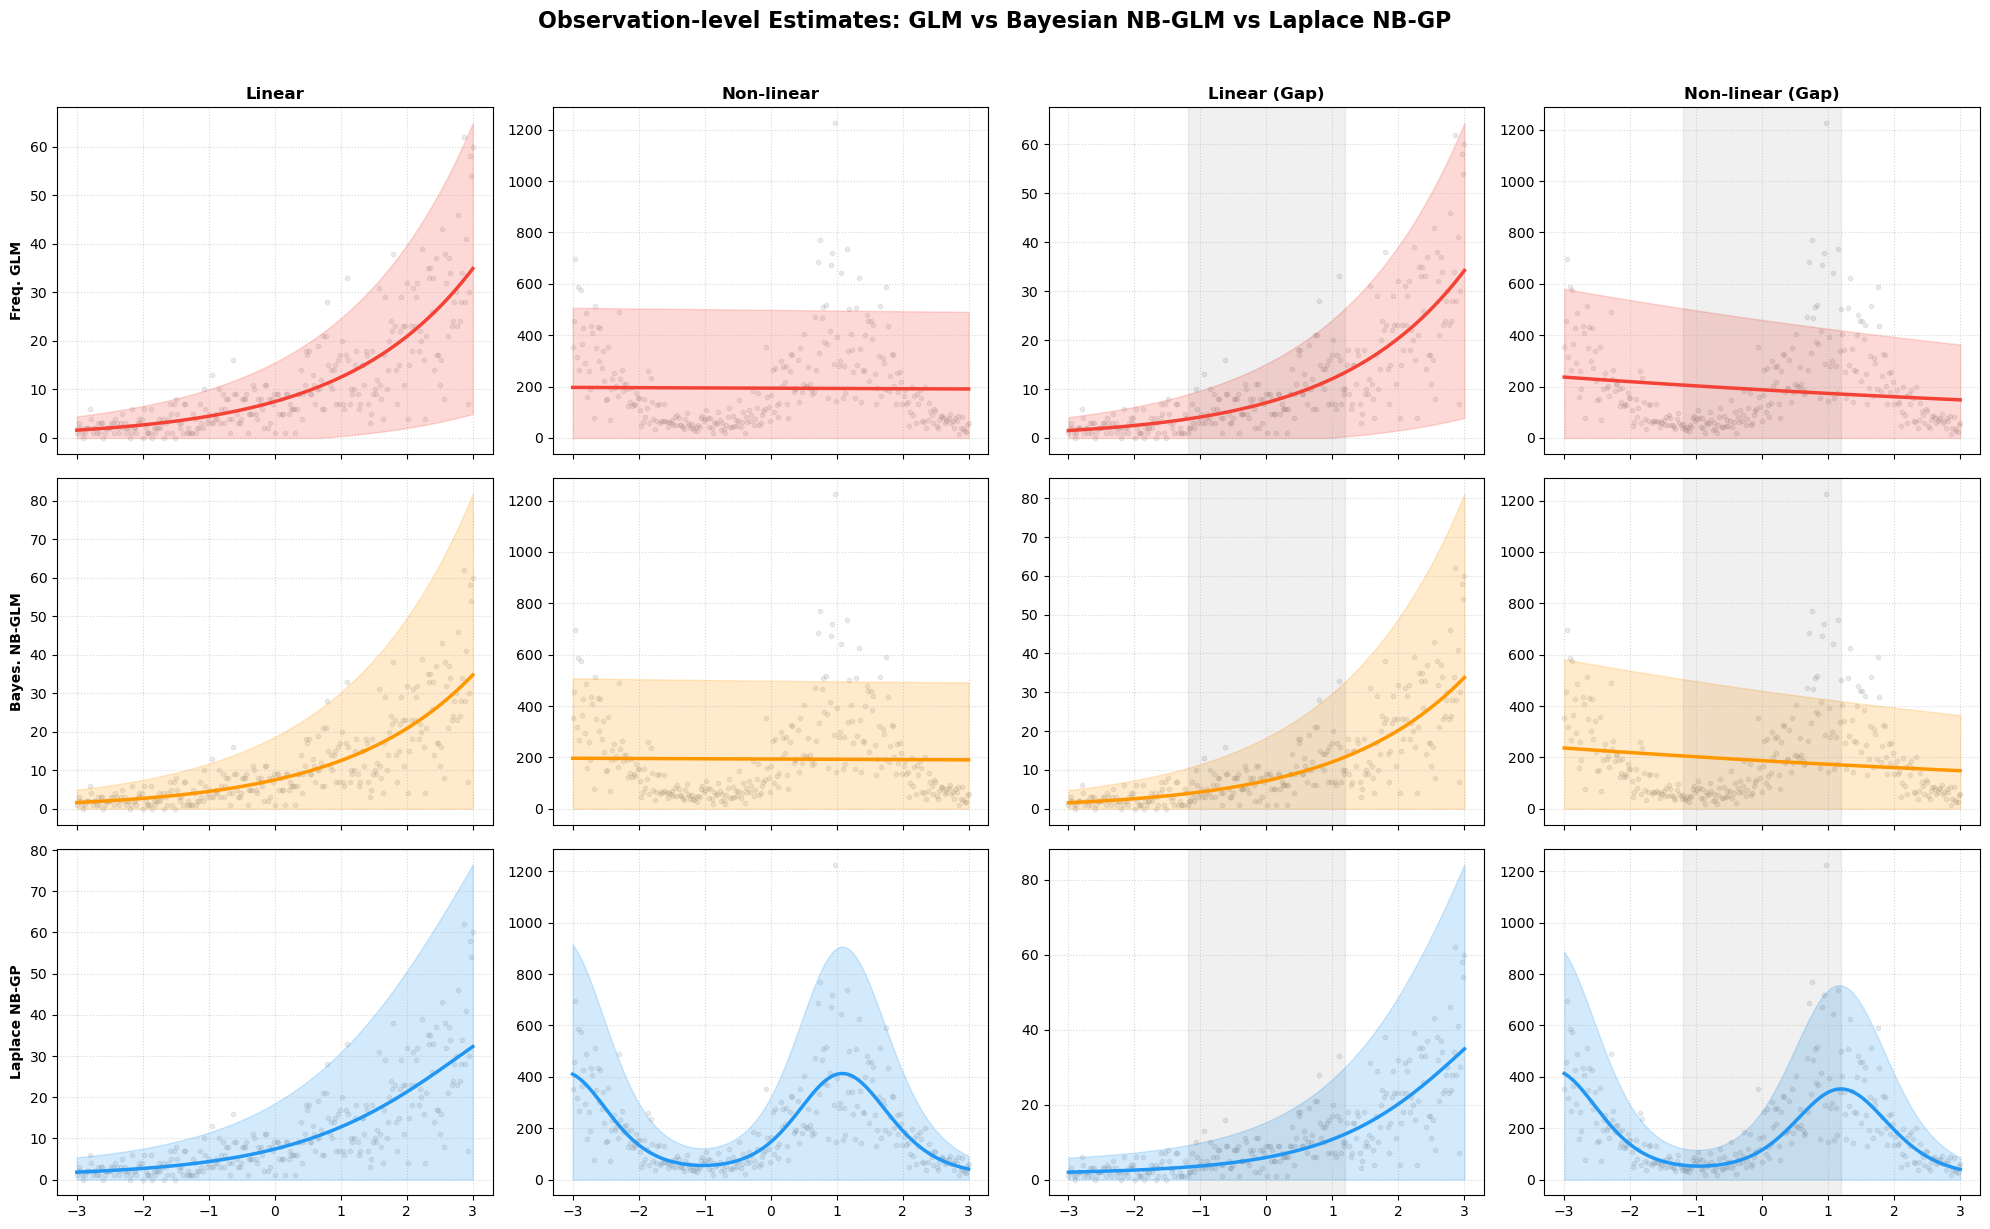

In [150]:
def total_pred_std(mu, theta, f_var):
    """SD combining NB dispersion and latent-function uncertainty (delta method)."""
    return np.sqrt(mu + mu**2 / theta + (mu**2) * f_var + 1e-8)


scenarios = list(datasets.keys())
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=False)
fig.suptitle("Observation-level Estimates: GLM vs Bayesian NB-GLM vs Laplace NB-GP",
              fontsize=16, fontweight='bold', y=1.02)

for col, scenario in enumerate(scenarios):
    data = datasets[scenario]
    X_test_np, y_all_np = data["X_test_np"], data["y_all_np"]
    gap = ~data["train_mask"]

    for row, m_name in enumerate(model_names):
        ax = axes[row, col]
        r = results[scenario][m_name]
        mu, theta, f_var = r["mu"], r["theta"], r["f_var"]
        std = total_pred_std(mu, theta, f_var)
        color = model_colors[m_name]

        ax.scatter(X_test_np, y_all_np, color='gray', alpha=0.15, s=10)
        ax.plot(X_test_np, mu, color=color, lw=2.5, label=r'Pred $\mu$')
        ax.fill_between(X_test_np, np.maximum(0, mu - 2 * std), mu + 2 * std,
                        color=color, alpha=0.2, label='±2 SD')
        if gap.any():
            ax.axvspan(X_test_np[gap].min(), X_test_np[gap].max(), color='black', alpha=0.06)

        if row == 0:
            ax.set_title(scenario, fontweight='bold')
        if col == 0:
            ax.set_ylabel(m_name, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Latent-level Estimates (5-8)


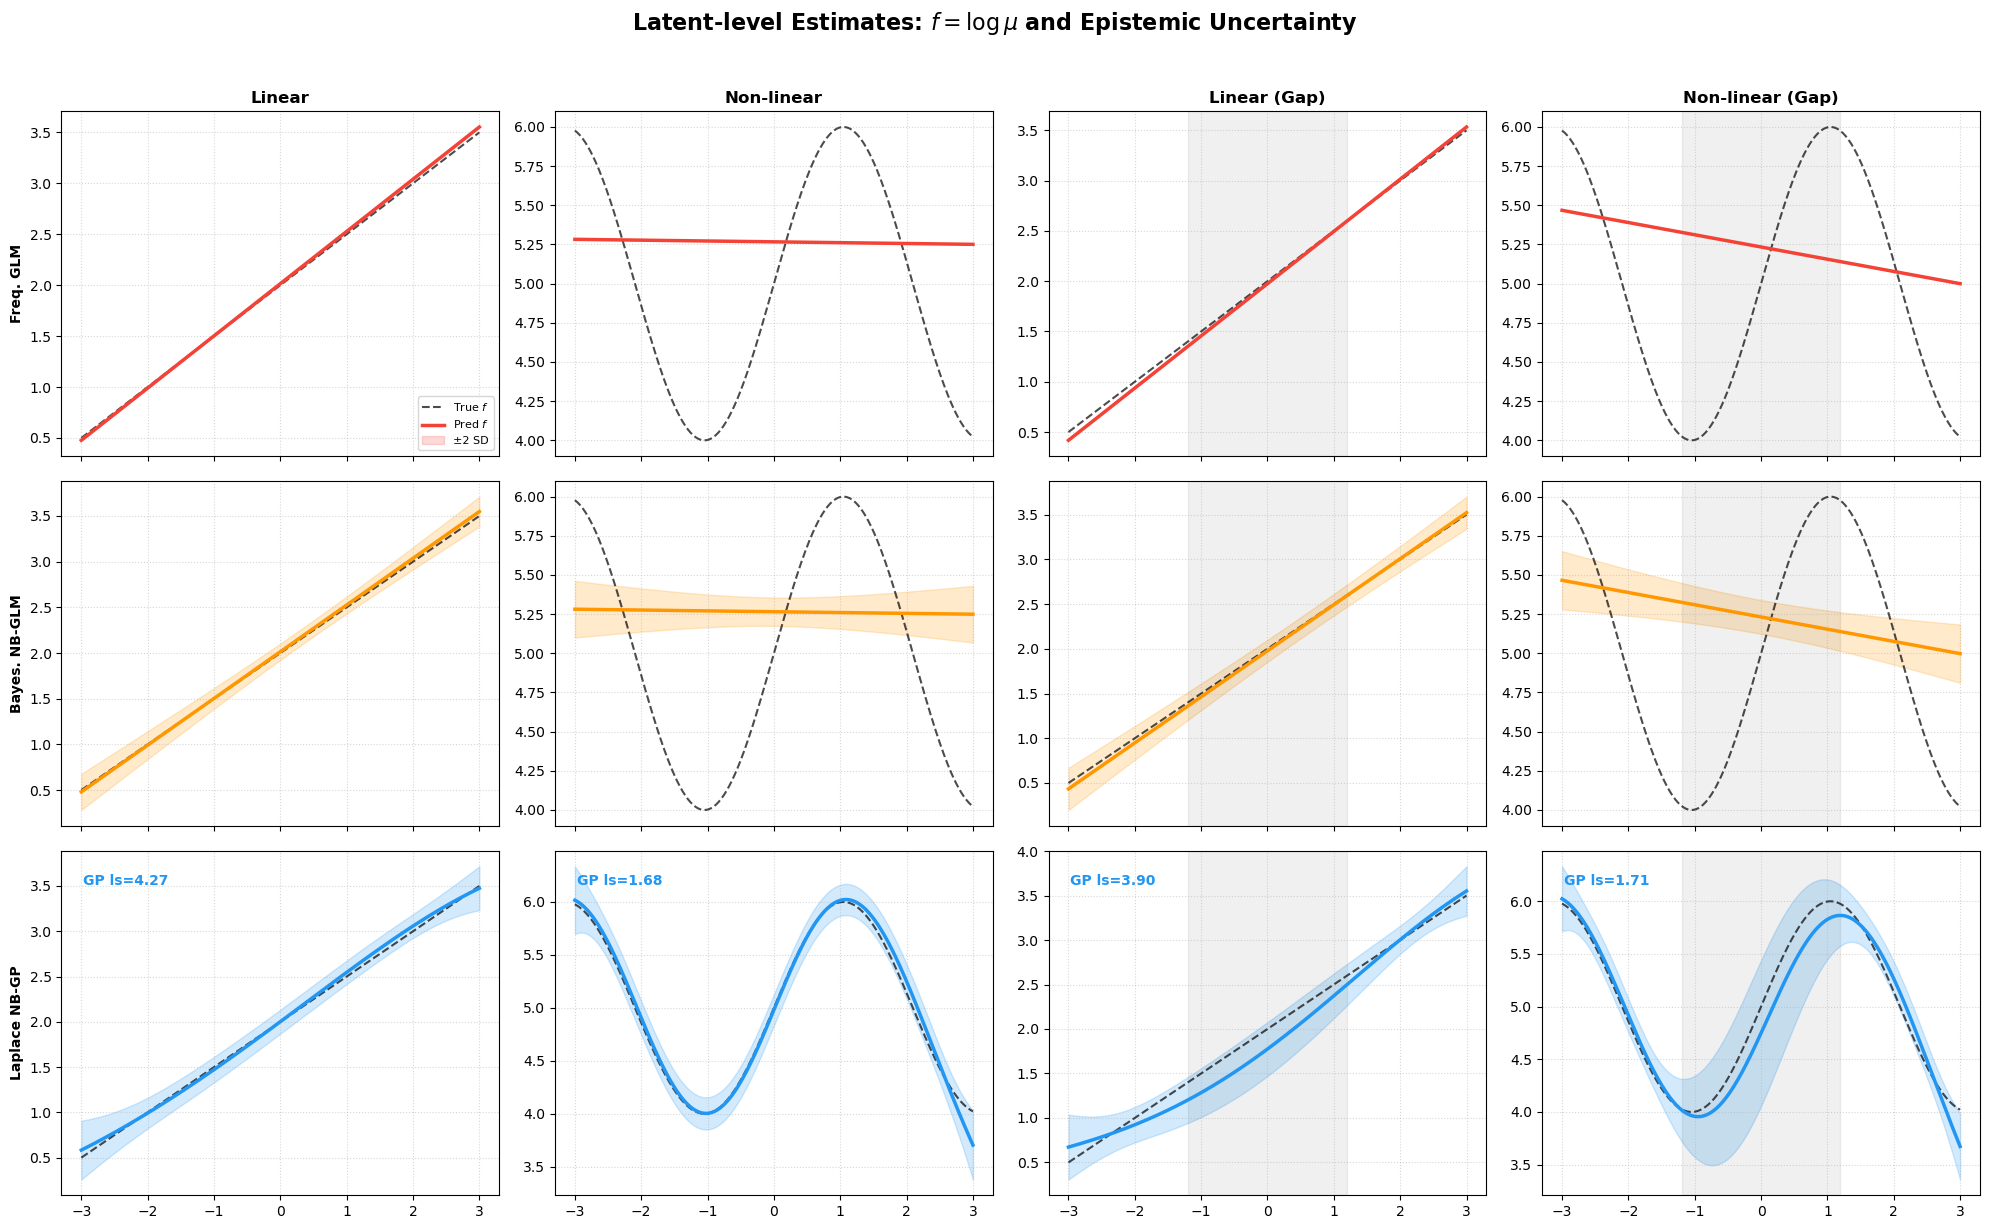

In [152]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=False)
fig.suptitle("Latent-level Estimates: $f = \\log\\mu$ and Epistemic Uncertainty",
              fontsize=16, fontweight='bold', y=1.02)

for col, scenario in enumerate(scenarios):
    data = datasets[scenario]
    X_test_np, f_true = data["X_test_np"], data["f_true"]
    gap = ~data["train_mask"]

    for row, m_name in enumerate(model_names):
        ax = axes[row, col]
        r = results[scenario][m_name]
        f_mean, f_var = r["f_mean"], r["f_var"]
        color = model_colors[m_name]

        ax.plot(X_test_np, f_true, color='black', ls='--', lw=1.5, alpha=0.7, label='True $f$')
        ax.plot(X_test_np, f_mean, color=color, lw=2.5, label='Pred $f$')
        ax.fill_between(X_test_np, f_mean - 2 * np.sqrt(f_var), f_mean + 2 * np.sqrt(f_var),
                        color=color, alpha=0.2, label='±2 SD')
        if gap.any():
            ax.axvspan(X_test_np[gap].min(), X_test_np[gap].max(), color='black', alpha=0.06)

        if row == 0:
            ax.set_title(scenario, fontweight='bold')
        if col == 0:
            ax.set_ylabel(m_name, fontweight='bold')
        if row == 2 and "length_scale" in r:
            ax.text(0.05, 0.9, f"GP ls={r['length_scale']:.2f}",
                    transform=ax.transAxes, fontweight='bold', color=color)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### Z-score Calibration with a Data Gap (9-11)


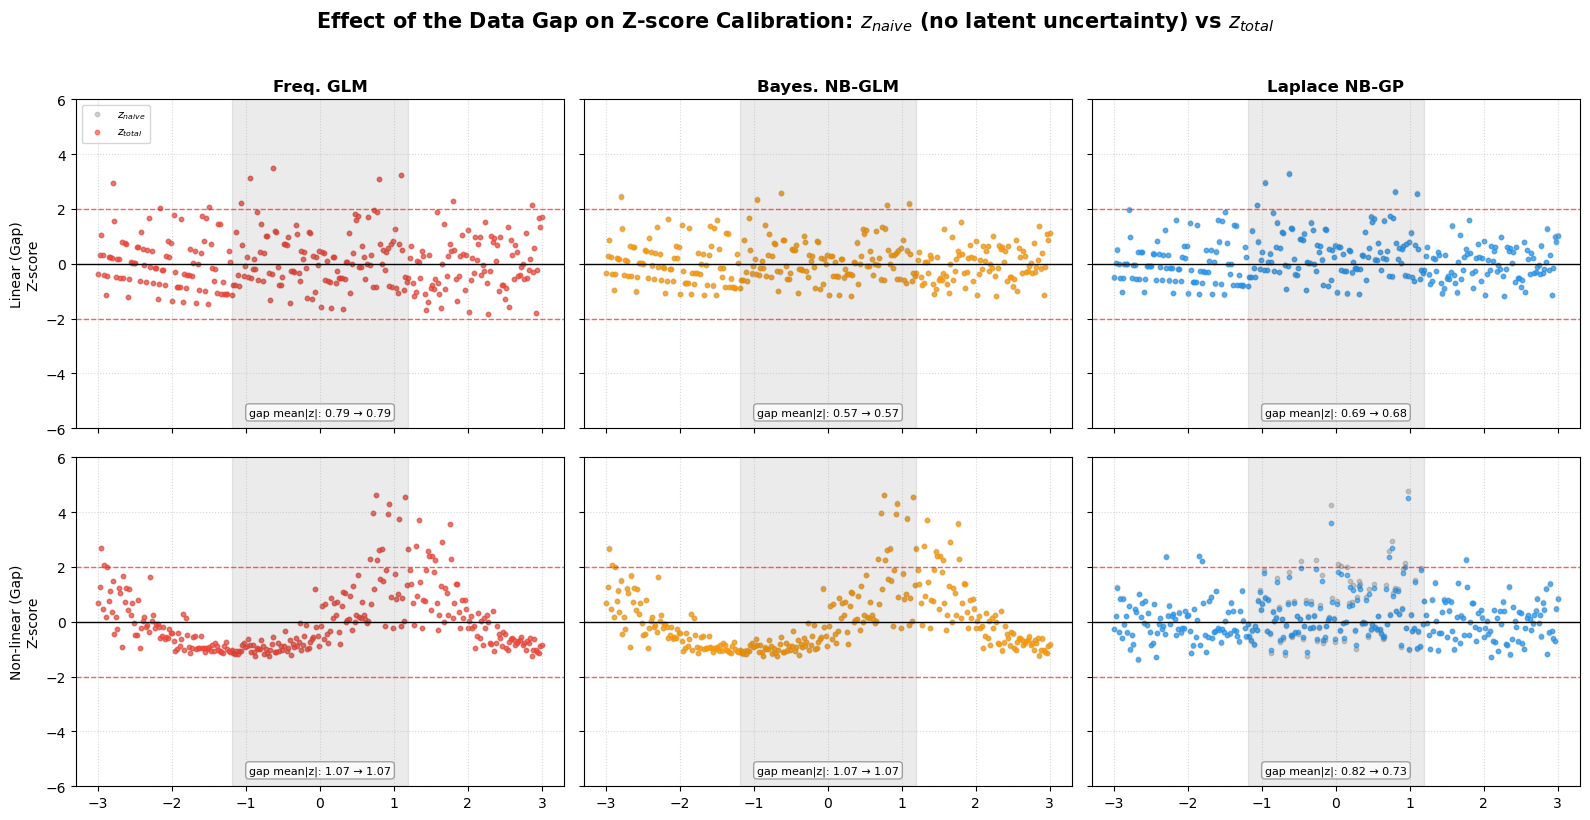

In [153]:
gap_scenarios = ["Linear (Gap)", "Non-linear (Gap)"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
fig.suptitle(r"Effect of the Data Gap on Z-score Calibration: $z_{naive}$ (no latent uncertainty) vs $z_{total}$",
              fontsize=15, fontweight='bold', y=1.02)

for row, scenario in enumerate(gap_scenarios):
    data = datasets[scenario]
    X_test_np, y_all_np = data["X_test_np"], data["y_all_np"]
    gap = ~data["train_mask"]

    for col, m_name in enumerate(model_names):
        ax = axes[row, col]
        r = results[scenario][m_name]
        mu, theta, f_var = r["mu"], r["theta"], r["f_var"]

        std_naive = np.sqrt(mu + mu**2 / theta + 1e-8)
        std_total = total_pred_std(mu, theta, f_var)
        z_naive = (y_all_np - mu) / std_naive
        z_total = (y_all_np - mu) / std_total
        color = model_colors[m_name]

        ax.scatter(X_test_np, z_naive, color='gray', s=10, alpha=0.35, label=r'$z_{naive}$')
        ax.scatter(X_test_np, z_total, color=color, s=10, alpha=0.6, label=r'$z_{total}$')
        ax.axhline(0, color='black', lw=1)
        ax.axhline(2, color='red', ls='--', lw=1, alpha=0.6)
        ax.axhline(-2, color='red', ls='--', lw=1, alpha=0.6)
        if gap.any():
            ax.axvspan(X_test_np[gap].min(), X_test_np[gap].max(), color='black', alpha=0.08)
            gap_abs_naive = np.abs(z_naive[gap]).mean()
            gap_abs_total = np.abs(z_total[gap]).mean()
            ax.text(0.5, 0.04, f"gap mean|z|: {gap_abs_naive:.2f} → {gap_abs_total:.2f}",
                    transform=ax.transAxes, ha='center', fontsize=8,
                    bbox=dict(boxstyle='round', fc='white', alpha=0.7, ec='gray'))
        ax.set_ylim(-6, 6)

        if row == 0:
            ax.set_title(m_name, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"{scenario}\nZ-score")
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### Bonus —  $\mathrm{SD}_{total}$ vs $\mathrm{SD}_{naive}$

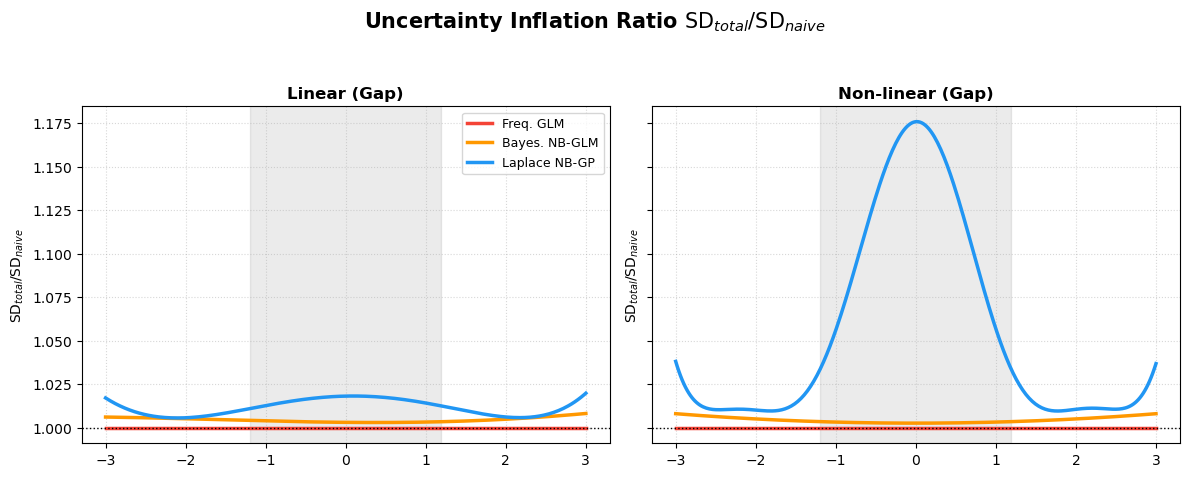

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
fig.suptitle(r"Uncertainty Inflation Ratio $\mathrm{SD}_{total} / \mathrm{SD}_{naive}$",
              fontsize=15, fontweight='bold', y=1.05)
for ax, scenario in zip(axes, gap_scenarios):
    data = datasets[scenario]
    X_test_np = data["X_test_np"]
    gap = ~data["train_mask"]

    for m_name in model_names:
        r = results[scenario][m_name]
        mu, theta, f_var = r["mu"], r["theta"], r["f_var"]
        std_naive = np.sqrt(mu + mu**2 / theta + 1e-8)
        std_total = total_pred_std(mu, theta, f_var)
        ratio = std_total / std_naive
        ax.plot(X_test_np, ratio, color=model_colors[m_name], lw=2.5, label=m_name)

    ax.axhline(1.0, color='black', lw=1, ls=':')
    if gap.any():
        ax.axvspan(X_test_np[gap].min(), X_test_np[gap].max(), color='black', alpha=0.08)
    ax.set_title(scenario, fontweight='bold')
    ax.set_ylabel(r'$\mathrm{SD}_{total} / \mathrm{SD}_{naive}$')
    ax.grid(True, linestyle=':', alpha=0.5)

axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

## Gene-by-Gene Pipeline

In [39]:
import pickle

X_tr_t  = torch.tensor(X_hc_scaled,  dtype=torch.float32).to(DEVICE)
X_all_t = torch.tensor(X_all_scaled, dtype=torch.float32).to(DEVICE)

ZSCORE_METHOD = "quantile"   # "pearson" | "quantile"
RANDOM_SEED   = 42

BGLM_MAX_EPOCHS = 300
LAP_MAX_EPOCHS  = 300

N_all = len(adata)

SAVE_DIR = "./NB_GP/saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Models will be saved to: {SAVE_DIR}")
print(f"Device         : {DEVICE}")
print(f"Target genes   : {len(target_names)}  (stratified selection)")
print(f"HC samples     : {is_hc.sum()} | All samples: {N_all}")

gene_meta = []


def _sync():
    """Flush GPU queue before reading the wall clock."""
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

def _fmt(v):
    return f"{v:.2f}" if v is not None else "NA"


Models will be saved to: ./NB_GP/saved_models
Device         : cuda
Target genes   : 52  (stratified selection)
HC samples     : 996 | All samples: 3159


In [23]:
for i, (g_name, g_idx) in enumerate(zip(target_names, target_indices)):
    y_hc   = Y_raw[is_hc, g_idx]
    y_tr_t = torch.tensor(y_hc, dtype=torch.float32).to(DEVICE)

    det_rate_hc   = float((y_hc > 0).mean())
    hc_mean_count = float(y_hc.mean())

    meta = {
        "gene": g_name,
        "det_rate_hc": det_rate_hc,
        "hc_mean_count": hc_mean_count,
    }

    # 1. GLM (statsmodels)
    _sync(); t0 = time.perf_counter()
    glm = NBGLM().fit(X_hc_scaled, y_hc)
    _sync(); meta["time_glm_s"] = time.perf_counter() - t0
    meta["theta_glm"] = glm.theta_

    with open(os.path.join(SAVE_DIR, f"{g_name}_glm.pkl"), "wb") as f:
        pickle.dump({"model": glm, "theta": glm.theta_}, f)
    del glm

    # 2. Bayesian NB-GLM
    _sync(); t0 = time.perf_counter()
    bglm, beta_map, neg_H = train_bayesian_nbglm(X_tr_t, y_tr_t, max_epochs=BGLM_MAX_EPOCHS)
    _sync(); meta["time_bglm_s"] = time.perf_counter() - t0
    meta["theta_bglm"] = bglm.theta.item()

    torch.save({
        "state_dict": bglm.state_dict(),
        "beta_map": beta_map.cpu(),
        "neg_H": neg_H.cpu(),
    }, os.path.join(SAVE_DIR, f"{g_name}_bglm.pt"))
    del bglm, beta_map, neg_H

    # 3. Laplace NB-GP
    _sync(); t0 = time.perf_counter()
    lap_model, f_map = train_laplace_nbgp(X_tr_t, y_tr_t, max_epochs=LAP_MAX_EPOCHS)
    _sync(); meta["time_lap_s"] = time.perf_counter() - t0
    meta["theta_lap"] = lap_model.theta.item()

    torch.save({
        "state_dict": lap_model.state_dict(),
        "f_map": f_map.cpu(),
    }, os.path.join(SAVE_DIR, f"{g_name}_laplace.pt"))
    del lap_model, f_map

    gene_meta.append(meta)

    # Empty GPU cache to strictly prevent fragmentation over time
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    print(
        f"[{i+1:3d}/{len(target_names)}] {g_name:<22s} "
        f"det={det_rate_hc:.2f} mean={hc_mean_count:6.1f}  "
        f"\u03b8: glm={_fmt(meta['theta_glm'])} bglm={meta['theta_bglm']:.2f} lap={meta['theta_lap']:.2f}  |  "
        f"t: {meta['time_glm_s']:.1f}+{meta['time_bglm_s']:.1f}+{meta['time_lap_s']:.1f}s"
    )

df_meta = pd.DataFrame(gene_meta)

time_cols = ["time_glm_s", "time_bglm_s", "time_lap_s"]
print(f"\nDone. Trained & saved {len(target_names)} genes x 3 models -> {SAVE_DIR}")
print("\nTraining time summary (seconds):")
print(df_meta[time_cols].describe().loc[["mean", "std", "min", "max"]].round(2).to_string())

df_meta.to_csv("./NB_GP/gene_meta.csv", index=False)
print("Gene metadata saved to CSV.")

[  1/52] ENSG00000158292.8      det=0.53 mean=  11.2  θ: glm=0.30 bglm=0.30 lap=0.34  |  t: 0.0+5.3+9.1s
[  2/52] ENSG00000100276.11     det=0.25 mean=   3.6  θ: glm=0.10 bglm=0.11 lap=0.15  |  t: 0.0+16.6+7.0s
[  3/52] ENSG00000179761.13     det=0.64 mean=  12.6  θ: glm=0.36 bglm=0.37 lap=0.43  |  t: 0.0+2.6+8.5s
[  4/52] ENSG00000196826.7      det=0.21 mean=   2.9  θ: glm=0.09 bglm=0.11 lap=0.11  |  t: 0.0+16.2+6.8s
[  5/52] ENSG00000250021.7      det=0.62 mean=  52.2  θ: glm=0.31 bglm=0.31 lap=0.44  |  t: 0.0+2.9+8.6s
[  6/52] ENSG00000127325.20     det=0.63 mean=  18.4  θ: glm=0.38 bglm=0.38 lap=0.44  |  t: 0.0+3.2+8.6s
[  7/52] ENSG00000105976.17     det=0.64 mean=  23.9  θ: glm=0.36 bglm=0.36 lap=0.56  |  t: 0.0+6.8+8.5s
[  8/52] ENSG00000187079.20     det=0.58 mean=  18.2  θ: glm=0.32 bglm=0.31 lap=0.51  |  t: 0.0+6.8+8.4s
[  9/52] ENSG00000213088.15     det=0.61 mean=  77.3  θ: glm=0.33 bglm=0.34 lap=1.12  |  t: 0.0+1.4+8.6s
[ 10/52] ENSG00000203811.2      det=0.56 mean= 131.2 

### Z-score Scoring


In [44]:
z_glm_all  = np.full((N_all, len(target_names)), np.nan, dtype=np.float32)
z_bglm_all = np.full((N_all, len(target_names)), np.nan, dtype=np.float32)
z_lap_all  = np.full((N_all, len(target_names)), np.nan, dtype=np.float32)

# Posterior predictive check용 HC 예측 평균(mu) 저장
n_hc = int(is_hc.sum())
mu_glm_hc  = np.full((n_hc, len(target_names)), np.nan, dtype=np.float32)
mu_bglm_hc = np.full((n_hc, len(target_names)), np.nan, dtype=np.float32)
mu_lap_hc  = np.full((n_hc, len(target_names)), np.nan, dtype=np.float32)

MC_SAMPLES = 2000
n_features = X_tr_t.shape[-1]

_sync()
t_start = time.perf_counter()

for i, (g_name, g_idx) in enumerate(zip(target_names, target_indices)):
    y_all  = Y_raw[:, g_idx]
    y_hc   = y_all[is_hc]
    y_tr_t = torch.tensor(y_hc, dtype=torch.float32).to(DEVICE)

    # 1. GLM
    with open(os.path.join(SAVE_DIR, f"{g_name}_glm.pkl"), "rb") as f:
        glm_ckpt = pickle.load(f)
    z_glm_all[:, i], mu_glm, _ = score_glm(
        glm_ckpt["model"], X_all_scaled, y_all, method=ZSCORE_METHOD, seed=RANDOM_SEED
    )
    mu_glm_hc[:, i] = mu_glm[is_hc]
    del glm_ckpt

    # 2. Bayesian NB-GLM
    ckpt = torch.load(os.path.join(SAVE_DIR, f"{g_name}_bglm.pt"), map_location=DEVICE)
    bglm = BayesianNBGLM(n_features).to(DEVICE)
    bglm.load_state_dict(ckpt["state_dict"])
    bglm.eval()
    beta_map = ckpt["beta_map"].to(DEVICE)
    neg_H    = ckpt["neg_H"].to(DEVICE)
    z_bglm_all[:, i], mu_bglm, _ = score_bayes_glm(
        bglm, beta_map, neg_H, X_all_t, y_all,
        method=ZSCORE_METHOD, n_samples=MC_SAMPLES, seed=RANDOM_SEED,
    )
    mu_bglm_hc[:, i] = mu_bglm[is_hc]
    del bglm, beta_map, neg_H, ckpt

    # 3. Laplace NB-GP
    ckpt = torch.load(os.path.join(SAVE_DIR, f"{g_name}_laplace.pt"), map_location=DEVICE)
    lap_model = LaplaceNBGP(n_features).to(DEVICE)
    lap_model.load_state_dict(ckpt["state_dict"])
    lap_model.eval()
    f_map = ckpt["f_map"].to(DEVICE)
    z_lap_all[:, i], mu_lap, _ = score_laplace(
        lap_model, f_map, X_tr_t, y_tr_t, X_all_t, y_all,
        method=ZSCORE_METHOD, n_samples=MC_SAMPLES, seed=RANDOM_SEED,
    )
    mu_lap_hc[:, i] = mu_lap[is_hc]
    del lap_model, f_map, ckpt

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    if (i + 1) % 20 == 0 or (i + 1) == len(target_names):
        print(f"[{i+1:3d}/{len(target_names)}] scored")

_sync()
print(f"\nDone. Z-score matrices: {z_glm_all.shape}  ({time.perf_counter() - t_start:.1f}s total)")


[ 20/52] scored
[ 40/52] scored
[ 52/52] scored

Done. Z-score matrices: (3159, 52)  (3.4s total)


### QC Metrics & Gene Filtering

GLM         — valid: 49/52 (94.2%)
fail_reason
Biased_Mean High_Std(Underfit)    2
Biased_Mean                       1

Bayes-GLM   — valid: 52/52 (100.0%)
Series([], )

Laplace-GP  — valid: 49/52 (94.2%)
fail_reason
Low_Std(Overfit)    3



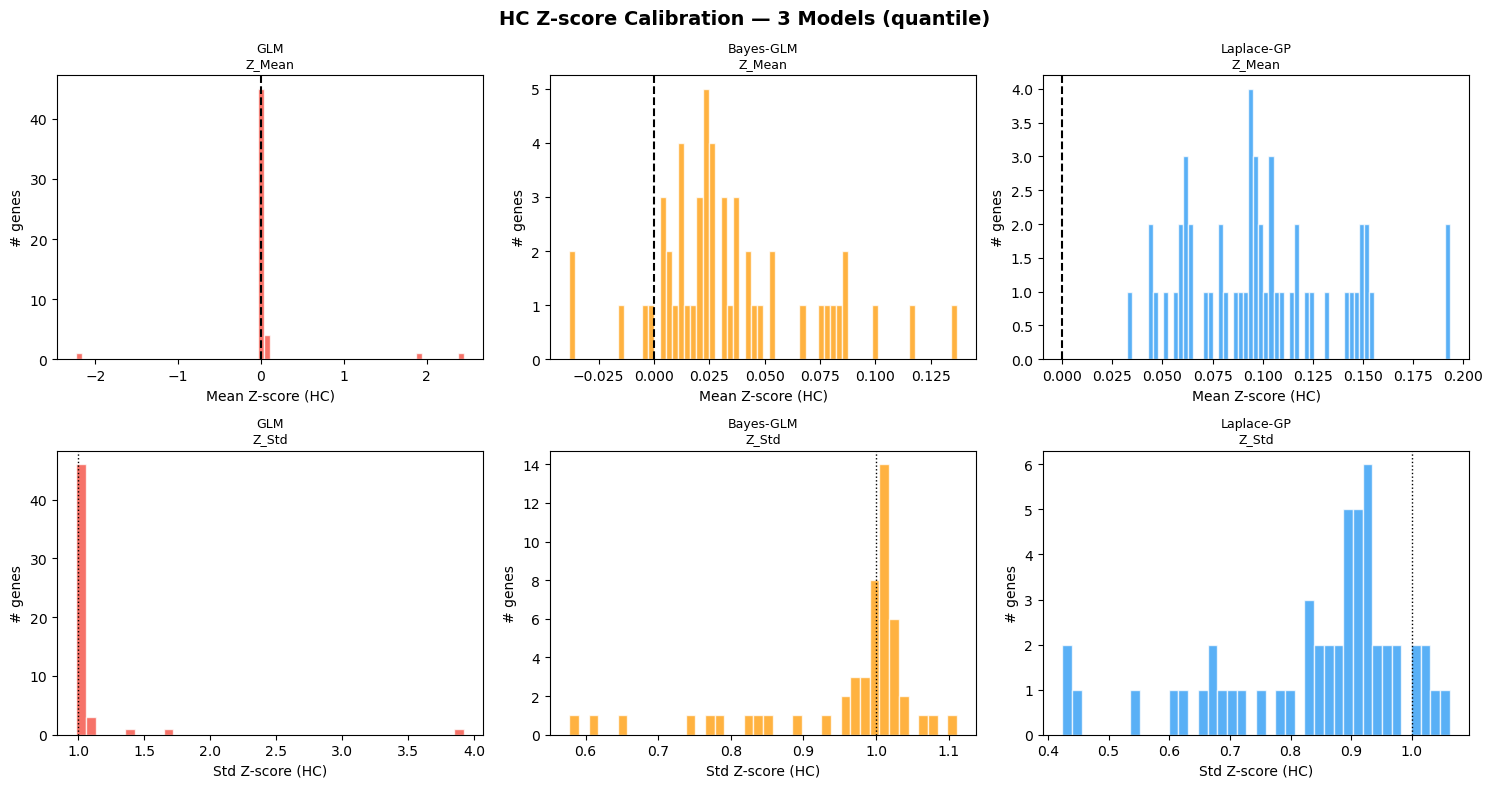

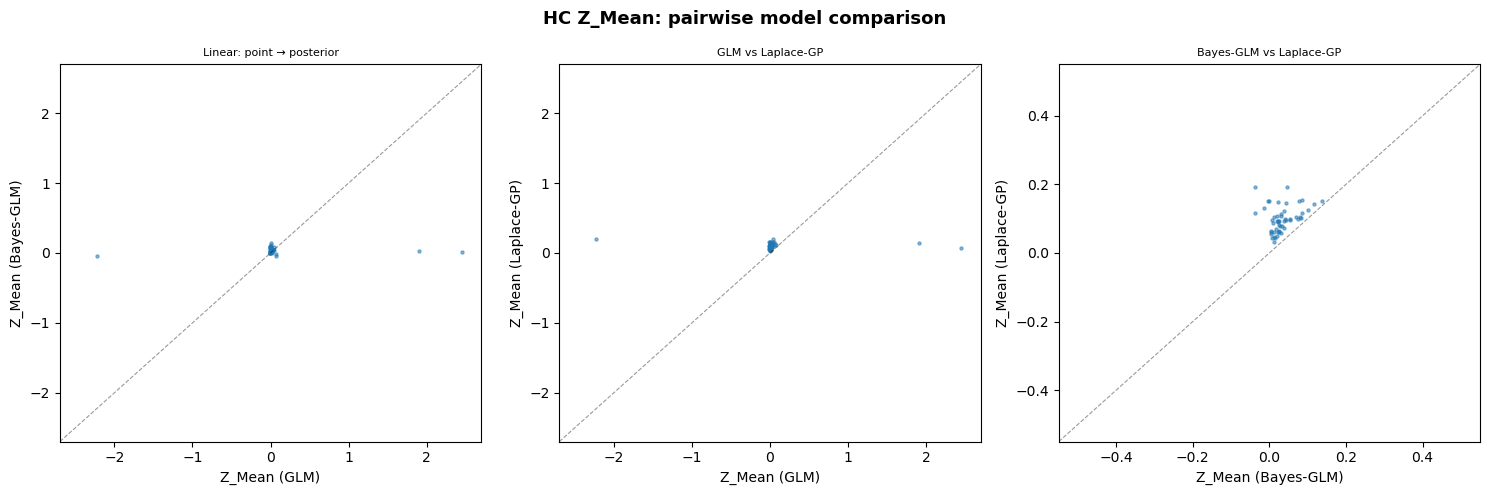

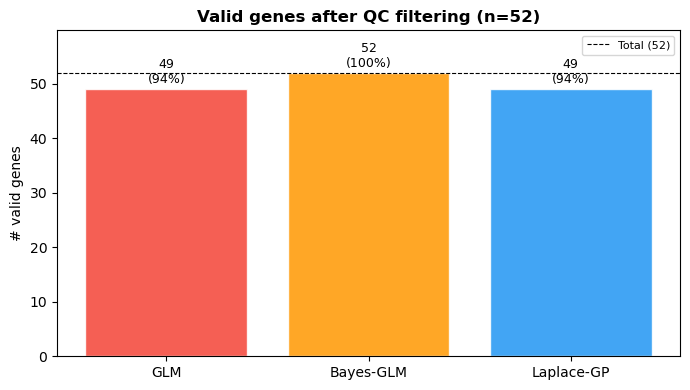

In [45]:
## QC Metrics & Gene Filtering
def compute_hc_qc(
    z_matrix: np.ndarray, is_hc: np.ndarray, gene_names: list
) -> pd.DataFrame:
    """
    Z-score QC strictly on HC samples per gene.
    z_matrix holds z-scores for ALL samples (N_all x n_genes), so we must
    slice to HC rows before computing per-gene moments.
    """
    z_hc   = z_matrix[is_hc, :]
    z_mean = np.nanmean(z_hc, axis=0)
    z_std  = np.nanstd(z_hc,  axis=0)
    return pd.DataFrame({"gene": gene_names, "Z_Mean": z_mean, "Z_Std": z_std})


def filter_valid_genes(
    df_meta: pd.DataFrame,
    df_qc: pd.DataFrame,
    z_mean_th: float = 0.3,       # |Z_Mean| <= 0.3
    z_std_min: float = 0.5,       # Z_Std in [0.5, 1.5]
    z_std_max: float = 1.5,
) -> pd.DataFrame:
    df = df_meta.merge(df_qc, on="gene")

    m_zmean = df["Z_Mean"].abs()  <= z_mean_th
    m_zstd  = (df["Z_Std"] >= z_std_min) & (df["Z_Std"] <= z_std_max)

    df["valid"]       =  m_zmean & m_zstd
    df["fail_reason"] = ""
    df.loc[~m_zmean, "fail_reason"] += "Biased_Mean "
    df.loc[df["Z_Std"] < z_std_min, "fail_reason"] += "Low_Std(Overfit) "
    df.loc[df["Z_Std"] > z_std_max, "fail_reason"] += "High_Std(Underfit) "
    df["fail_reason"] = df["fail_reason"].str.strip()
    return df


# ── Compute QC (Pure Control Setup) ───────────────────────────────
df_meta = pd.read_csv("./NB_GP/gene_meta.csv")
qc_glm  = compute_hc_qc(z_glm_all,  is_hc, target_names)
qc_bglm = compute_hc_qc(z_bglm_all, is_hc, target_names)
qc_lap  = compute_hc_qc(z_lap_all,  is_hc, target_names)

df_filter_glm  = filter_valid_genes(df_meta, qc_glm)
df_filter_bglm = filter_valid_genes(df_meta, qc_bglm)
df_filter_lap  = filter_valid_genes(df_meta, qc_lap)

for m_name, df_f in [
    ("GLM",       df_filter_glm),
    ("Bayes-GLM", df_filter_bglm),
    ("Laplace-GP",df_filter_lap),
]:
    n_valid = df_f["valid"].sum()
    print(f"{m_name:11s} — valid: {n_valid}/{len(df_f)} ({n_valid/len(df_f)*100:.1f}%)")
    reason_counts = (
        df_f.loc[~df_f["valid"] & df_f["fail_reason"].ne(""), "fail_reason"]
        .value_counts().head(5)
    )
    print(reason_counts.to_string())
    print()


## Results & Visualization
# ── 1. HC Z-score calibration: Z_Mean & Z_Std distributions (2 × 3) ─
method_configs = [
    ("GLM",        qc_glm,  "#F44336"),
    ("Bayes-GLM",  qc_bglm, "#FF9800"),
    ("Laplace-GP", qc_lap,  "#2196F3"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plt.suptitle(f"HC Z-score Calibration — 3 Models ({ZSCORE_METHOD})", fontsize=14, fontweight="bold")

for col, (m_name, qc_df, color) in enumerate(method_configs):
    # Top Row: Z_Mean distribution
    ax = axes[0, col]
    ax.hist(qc_df["Z_Mean"].dropna(), bins=64, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_title(f"{m_name}\nZ_Mean", fontsize=9)
    ax.set_xlabel("Mean Z-score (HC)"); ax.set_ylabel("# genes")

    # Bottom Row: Z_Std distribution
    ax = axes[1, col]
    ax.hist(qc_df["Z_Std"].dropna(), bins=40, color=color, alpha=0.75, edgecolor="white")
    ax.axvline(1.0, color="k", lw=1.0, ls=":")  # Ideal Standard Deviation reference
    ax.set_title(f"{m_name}\nZ_Std", fontsize=9)
    ax.set_xlabel("Std Z-score (HC)"); ax.set_ylabel("# genes")

plt.tight_layout()
plt.show()


# ── 2. Pairwise Model Comparison (Robust to NaNs) ─────────────────
pairs_layout = [
    ("GLM",       qc_glm,  "Bayes-GLM",  qc_bglm, "Linear: point → posterior"),
    ("GLM",       qc_glm,  "Laplace-GP", qc_lap,  "GLM vs Laplace-GP"),
    ("Bayes-GLM", qc_bglm, "Laplace-GP", qc_lap,  "Bayes-GLM vs Laplace-GP"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("HC Z_Mean: pairwise model comparison", fontsize=13, fontweight="bold")

for ax, (n1, df1, n2, df2, note) in zip(axes.flat, pairs_layout):
    m = df1.merge(df2, on="gene", suffixes=(f"_{n1.replace('-','')}", f"_{n2.replace('-','')}"))
    c1 = f"Z_Mean_{n1.replace('-','')}"
    c2 = f"Z_Mean_{n2.replace('-','')}"
    
    # Drop rows where either model produced a NaN for a gene to guarantee clean scatter
    m_clean = m.dropna(subset=[c1, c2])
    
    ax.scatter(m_clean[c1], m_clean[c2], s=5, alpha=0.5)
    
    # Calculate adaptive dynamic limits avoiding NaN interference
    lim = max(m_clean[[c1, c2]].abs().max().max(), 0.5) * 1.1 if len(m_clean) > 0 else 1.0
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.8, alpha=0.4)
    ax.set_xlabel(f"Z_Mean ({n1})"); ax.set_ylabel(f"Z_Mean ({n2})")
    ax.set_title(note, fontsize=8)

plt.tight_layout()
plt.show()


# ── 3. Valid-gene summary bar chart ───────────────────────────────
n_genes = len(target_names)
summary = {
    "GLM":        df_filter_glm["valid"].sum(),
    "Bayes-GLM":  df_filter_bglm["valid"].sum(),
    "Laplace-GP": df_filter_lap["valid"].sum(),
}
colors_bar = [c for _, _, c in method_configs]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary.keys(), summary.values(), color=colors_bar, alpha=0.85, edgecolor="white")
ax.set_ylim(0, n_genes * 1.15)
ax.axhline(n_genes, color="k", lw=0.8, ls="--", label=f"Total ({n_genes})")
for bar, v in zip(bars, summary.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5,
            f"{v}\n({v/n_genes*100:.0f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("# valid genes")
ax.set_title(f"Valid genes after QC filtering (n={n_genes})", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Posterior Predictive Check: Simulated vs Real Distribution

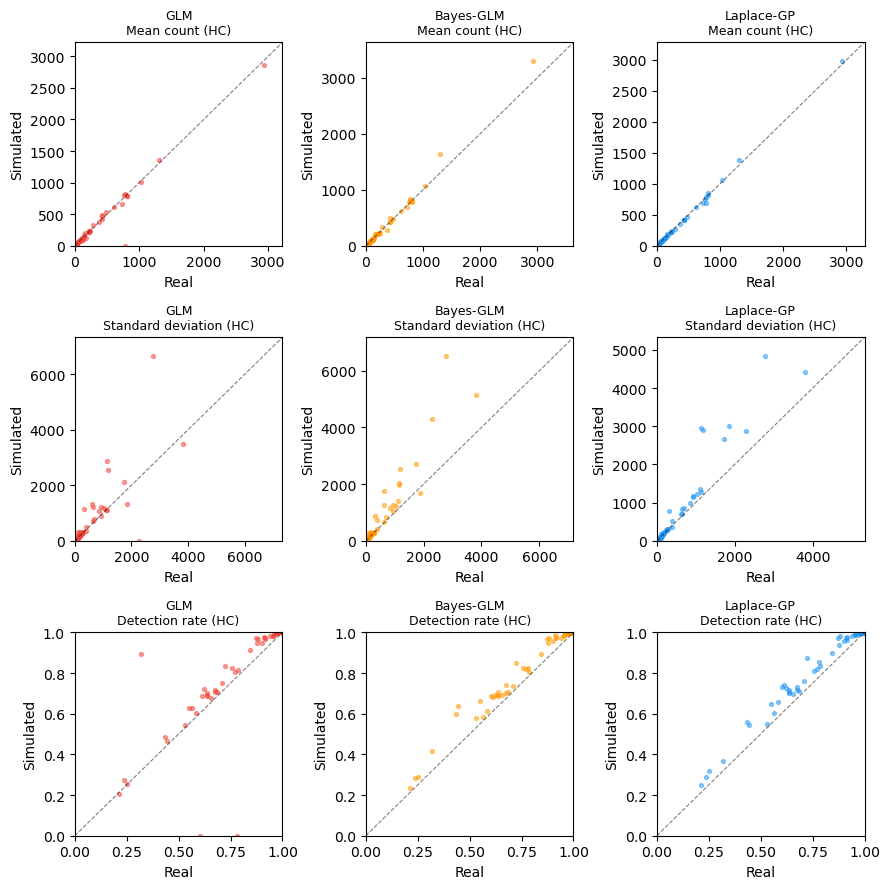

In [50]:
## Posterior Predictive Check: Simulated vs Real (HC)
def simulate_nb_counts(mu: np.ndarray, theta: float, rng: np.random.Generator) -> np.ndarray:
    """Sample synthetic counts y_sim ~ NB(mean=mu, dispersion=theta)."""
    theta = max(float(theta), 1e-4)
    p = np.clip(theta / (theta + mu + 1e-8), 1e-8, 1 - 1e-8)
    return rng.negative_binomial(theta, p)


rng_ppc = np.random.default_rng(RANDOM_SEED)
model_specs = [
    ("GLM",        mu_glm_hc,  "theta_glm",  "#F44336"),
    ("Bayes-GLM",  mu_bglm_hc, "theta_bglm", "#FF9800"),
    ("Laplace-GP", mu_lap_hc,  "theta_lap",  "#2196F3"),
]

ppc_rows = []
for i, (g_name, g_idx) in enumerate(zip(target_names, target_indices)):
    y_hc = Y_raw[is_hc, g_idx]
    real_mean = float(y_hc.mean())
    real_std = float(y_hc.std())
    real_det  = float((y_hc > 0).mean())

    for model_name, mu_hc_mat, theta_col, _ in model_specs:
        theta = df_meta.loc[df_meta["gene"] == g_name, theta_col].values[0]
        if theta is None or not np.isfinite(theta):
            continue

        y_sim = simulate_nb_counts(mu_hc_mat[:, i], theta, rng_ppc)
        ppc_rows.append({
            "gene": g_name, "model": model_name,
            "real_mean": real_mean, "sim_mean": float(y_sim.mean()),
            "real_std": real_std, "sim_std": float(y_sim.std()),
            "real_det":  real_det,  "sim_det":  float((y_sim > 0).mean()),
        })

df_ppc = pd.DataFrame(ppc_rows)


# ── Real vs Simulated scatter (3 x 3) ─────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(9, 9))

for col, (model_name, _, _, color) in enumerate(model_specs):
    sub = df_ppc[df_ppc["model"] == model_name]

    ax = axes[0, col]
    ax.scatter(sub["real_mean"], sub["sim_mean"], s=8, alpha=0.5, color=color)
    lim = max(sub[["real_mean", "sim_mean"]].max().max(), 1.0) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f"{model_name}\nMean count (HC)", fontsize=9)
    ax.set_xlabel("Real"); ax.set_ylabel("Simulated")
    
    ax = axes[1, col]
    ax.scatter(sub["real_std"], sub["sim_std"], s=8, alpha=0.5, color=color)
    lim = max(sub[["real_std", "sim_std"]].max().max(), 1.0) * 1.1
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_title(f"{model_name}\nStandard deviation (HC)", fontsize=9)
    ax.set_xlabel("Real"); ax.set_ylabel("Simulated")
    
    ax = axes[2, col]
    ax.scatter(sub["real_det"], sub["sim_det"], s=8, alpha=0.5, color=color)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{model_name}\nDetection rate (HC)", fontsize=9)
    ax.set_xlabel("Real"); ax.set_ylabel("Simulated")

plt.tight_layout()
plt.show()


In [49]:
from pathlib import Path

sample_ids = adata.obs_names.tolist()
hc_sample_ids = [sample_ids[idx] for idx, is_val in enumerate(is_hc) if is_val]

OUT_DIR = Path("/project/cfRNA_NormativeModeling/NB_GP")
OUT_DIR.mkdir(exist_ok=True)

tag = f"{ZSCORE_METHOD}_n{len(target_names)}"

for z_mat, label in [
    (z_glm_all,  "glm"),
    (z_bglm_all, "bayes_glm"),
    (z_lap_all,  "laplace"),
]:
    z_mat_hc = z_mat[is_hc, :]
    
    pd.DataFrame(z_mat_hc, index=hc_sample_ids, columns=target_names).to_csv(
        OUT_DIR / f"zscores_hc_{label}_{tag}.csv" 
    )

for df_f, label in [
    (df_filter_glm,  "glm"),
    (df_filter_bglm, "bayes_glm"),
    (df_filter_lap,  "laplace"),
]:
    df_f.to_csv(OUT_DIR / f"qc_{label}_{tag}.csv", index=False)

df_meta.to_csv(OUT_DIR / f"timing_{tag}.csv", index=False)

print(f"Saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    if tag in f.name:  
        print(f"  {f.name}")

Saved to: /project/cfRNA_NormativeModeling/NB_GP
  qc_bayes_glm_quantile_n52.csv
  qc_glm_quantile_n52.csv
  qc_laplace_quantile_n52.csv
  timing_quantile_n52.csv
  zscores_hc_bayes_glm_quantile_n52.csv
  zscores_hc_glm_quantile_n52.csv
  zscores_hc_laplace_quantile_n52.csv
